In [36]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from Bio import SeqIO
import geopandas as gpd
from itertools import combinations
from geopy.distance import geodesic
import fiona
import shapely
import simplekml
from fiona.drvsupport import supported_drivers
from shapely.geometry import Polygon
import json

In [ ]:
def logMatrix(matrix):
    """
    Log-normalize a matrix. 
    Author - Gytis Dudas
    """
    transformed_matrix = []
    for value in matrix:
        value = float(value)
        transformed_matrix.append(math.log(value))
    
    return transformed_matrix


def standardizeMatrix(matrix):
    """
    Calculate mean and stdev of matrix, standardize it.
    Author - Gytis Dudas
    """
    mean = 0   
    for value in matrix:
        mean += value

    mean /= len(matrix)
    
    variance = 0
    for value in matrix:
        variance += (value - mean) * (value - mean)
    variance /= len(matrix)

    stdev = math.sqrt(variance)

    standardized_matrix = []
    for value in matrix:
        standardized_matrix.append((value - mean) / stdev)
    
    return standardized_matrix


def convertToString(matrix):
    """
    Convert matrix to a string.
    Author - Gytis Dudas
    """
    string = ' '.join(map(str,matrix))
        
    return string


def predictorMatrixPlot(data_dictionary, region_list, name):
    """
    Generate origin and destination GLM matrices (original and linear) for integration into the BEAST discrete phylogeography model, and plot the resulting matrices.
    Requires a dictionary of sampling regions with predictor values, a list of regions, and the predictor name.
    """
    region_list = list(region_list)
    origin_matrix = np.array([[data_dictionary[origin]] * len(region_list) for origin in region_list]) ## rows with values from the same region (origin)
    origin_df = pd.DataFrame(origin_matrix, index=region_list, columns=region_list)

    destination_matrix = np.array([[data_dictionary[destination] for destination in region_list]] * len(region_list)) # columns with values from the same region (destination)
    destination_df = pd.DataFrame(destination_matrix, index=region_list, columns=region_list)
    
    origin_vector = np.array([data_dictionary[r] for r in region_list])
    destination_vector = np.array([data_dictionary[r] for r in region_list])
    # print(origin_vector)
    
    ## Log-transform and standardize
    transformed_origin = standardizeMatrix(logMatrix(origin_vector))
    transformed_destination = standardizeMatrix(logMatrix(destination_vector))
    
    
    string_origin = convertToString(transformed_origin)
    string_destination = convertToString(transformed_destination)
    
    ## Map region names to indices
    region_to_idx = {region: i for i, region in enumerate(region_list)}
    
    transformed_origin_vector = np.array([transformed_origin[region_to_idx[r]] for r in region_list])
    transformed_destination_vector = np.array([transformed_destination[region_to_idx[r]] for r in region_list])
    
    origin_matrix = np.tile(transformed_origin_vector.reshape(-1, 1), (1, len(region_list))) ## Construct origin matrix:
    destination_matrix = np.tile(transformed_destination_vector.reshape(1, -1), (len(region_list), 1)) # Construct destination matrix
    
    ## Convert to dataframes
    df_origin = pd.DataFrame(origin_matrix, index=region_list, columns=region_list)
    df_destination = pd.DataFrame(destination_matrix, index=region_list, columns=region_list)

    ## Save as separate origin and destination matrices
    df_origin.to_csv(
        f"/mnt/c/Files/wumv6_phylogeo/predictors/wmv6_NP_{name}_origin_predictor_matrix.txt",
        sep="\t",
        float_format="%.8f"
    )
    df_destination.to_csv(
        f"/mnt/c/Files/wumv6_phylogeo/predictors/wmv6_NP_{name}_destination_predictor_matrix.txt",
        sep="\t",
        float_format="%.8f"
    )
    
    ## plot predictor matrices
    df_combined = df_origin + df_destination

    plt.figure(figsize=(7, 6))
    mask = np.zeros_like(df_combined, dtype=bool)
    np.fill_diagonal(mask, True)  # diagonal = True
    sns.heatmap(df_combined, cmap="viridis", mask=mask, xticklabels=True, yticklabels=True)
    mpl.rcParams['font.size']=15
    plt.xlabel("Destination")
    plt.ylabel("Origin")
    plt.gca().invert_xaxis()

    return origin_matrix, destination_matrix, string_origin, string_destination

### For all predictors that can be represented as pairwise matrices, the predictorMatrixPlot function can be used directly by specifying the relevant variables.

### Special cases - where predictors require additional processing or custom handling - are described in the sections below.

## For temperature/precipitation seasonal index predictors

(array([[ 0.53565068,  0.53565068,  0.53565068,  0.53565068,  0.53565068,
          0.53565068,  0.53565068,  0.53565068,  0.53565068,  0.53565068,
          0.53565068,  0.53565068,  0.53565068,  0.53565068,  0.53565068,
          0.53565068,  0.53565068,  0.53565068,  0.53565068,  0.53565068,
          0.53565068,  0.53565068,  0.53565068,  0.53565068,  0.53565068,
          0.53565068,  0.53565068],
        [ 0.11372959,  0.11372959,  0.11372959,  0.11372959,  0.11372959,
          0.11372959,  0.11372959,  0.11372959,  0.11372959,  0.11372959,
          0.11372959,  0.11372959,  0.11372959,  0.11372959,  0.11372959,
          0.11372959,  0.11372959,  0.11372959,  0.11372959,  0.11372959,
          0.11372959,  0.11372959,  0.11372959,  0.11372959,  0.11372959,
          0.11372959,  0.11372959],
        [ 0.90181841,  0.90181841,  0.90181841,  0.90181841,  0.90181841,
          0.90181841,  0.90181841,  0.90181841,  0.90181841,  0.90181841,
          0.90181841,  0.90181841,  0.90

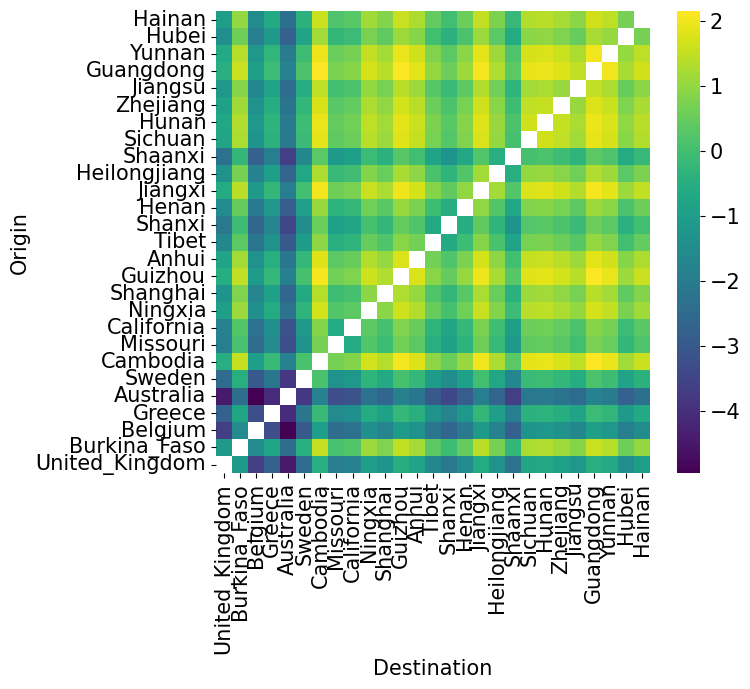

In [27]:
precipitation_min_max_avg = {key: value for key, value in precipitation_min_max_avg.items()}

prec_amplitude = {
    key: round(value[1] - value[0], 4)
    for key, value in precipitation_min_max_avg.items()
}
# get sorted keys by value
sorted_keys = sorted(prec_amplitude, key=prec_amplitude.get)
ranks = {key: rank + 1 for rank, key in enumerate(sorted_keys)} ## assign rank based on sorted position
prec_seasonal_index = {key: ranks[key] for key in prec_amplitude}
# print(prec_seasonal_index)

predictorMatrixPlot(prec_seasonal_index, NP_region_list, "precipitation_seasonal_index")

## For neighboring countries with shared borders predictor

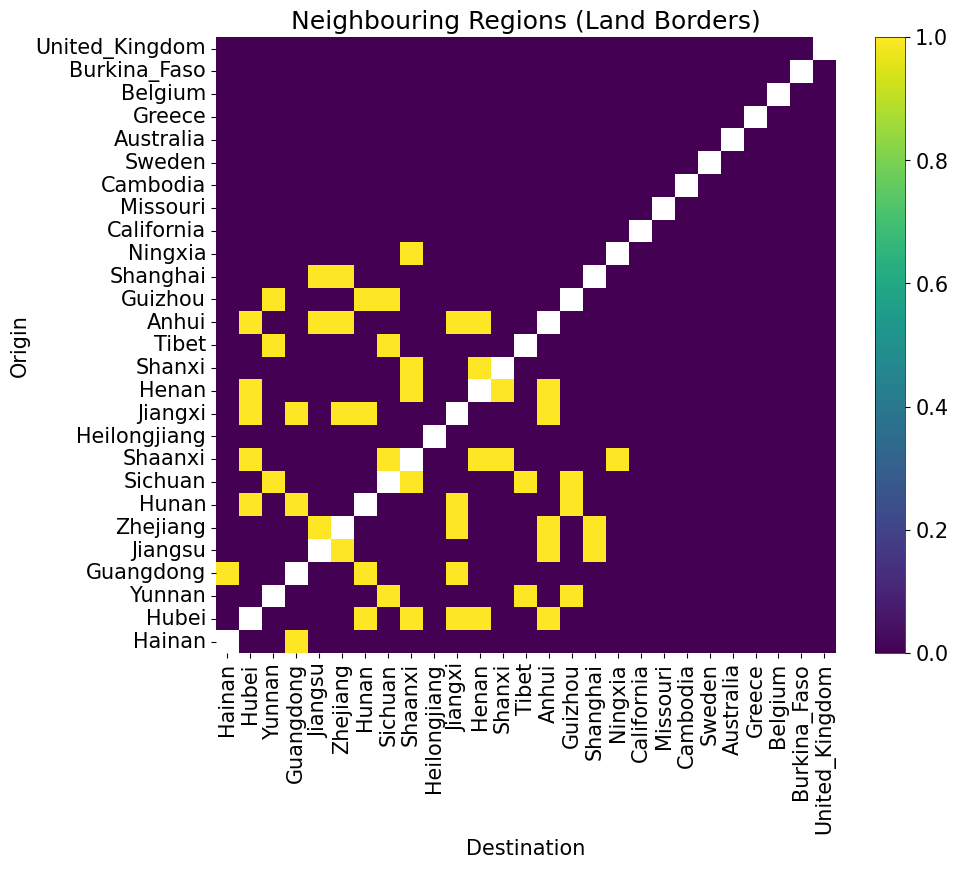

In [31]:
neighboring_countries = {key: [value for value in values] for key, values in neighboring_countries.items()}

matrix = np.zeros((len(NP_region_list), len(NP_region_list)), dtype=int)
## Map countries to indices
country_index = {country: i for i, country in enumerate(NP_region_list)}

for country, neighbors in neighboring_countries.items(): ## fill the matrix only if both countries are in "regions"
    if country in country_index:
        for neighbor in neighbors:
            if neighbor in country_index:
                i = country_index[country]
                j = country_index[neighbor]
                matrix[i][j] = 1
                matrix[j][i] = 1 

df = pd.DataFrame(matrix, index=NP_region_list, columns=NP_region_list)
df.to_csv(
    "/mnt/c/Files/wumv6_phylogeo/predictors/wmv6_NP_land_borders_predictor_matrix.txt",
    sep="\t",
    float_format="%.8f"
)

import matplotlib as mpl

mask = np.zeros_like(matrix, dtype=bool)
np.fill_diagonal(mask, True)  
mpl.rcParams['font.size']=15
plt.figure(figsize=(10, 8))
ax = sns.heatmap(df, cmap="viridis", xticklabels=True, yticklabels=True, mask=mask, cbar=True)
cbar = ax.collections[0].colorbar  
for spine in cbar.ax.spines.values():
    spine.set_edgecolor('black')  
    spine.set_linewidth(0.5)      

plt.title("Neighbouring Regions (Land Borders)")
plt.xlabel("Destination")
plt.ylabel("Origin")
plt.gca().invert_yaxis()

## For distance between region centroids predictor

/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before thi

    name  centroid_lat  centroid_lon
0  anhui     31.832276    117.228039
        name  centroid_lat  centroid_lon
0  Australia    -25.732311    134.491119
      name  centroid_lat  centroid_lon
0  Belgium     50.670073      4.581976
           name  centroid_lat  centroid_lon
0  burkina_faso     12.267988     -1.740923
         name  centroid_lat  centroid_lon
0  California     36.551343   -121.320102
       name  centroid_lat  centroid_lon
0  cambodia     12.478458    104.746514
        name  centroid_lat  centroid_lon
0  chongqing     30.051671    107.877438
          name  centroid_lat  centroid_lon
0  Connecticut      41.58981    -72.736601
     name  centroid_lat  centroid_lon
0  greece     37.972919     23.866959
        name  centroid_lat  centroid_lon
0  guangdong     22.912986    113.341439
      name  centroid_lat  centroid_lon
0  guizhou     26.819968    106.875671
     name  centroid_lat  centroid_lon
0  hainan     17.883595    111.241771
           name  centroid_lat  cen

/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/tmp/ipykernel_4869/1775793129.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before thi

       name  centroid_lat  centroid_lon
0  missouri     38.365445    -92.470336
      name  centroid_lat  centroid_lon
0  ningxia     37.264947    106.163951
      name  centroid_lat  centroid_lon
0  shaanxi     35.198317    108.863901
       name  centroid_lat  centroid_lon
0  shanghai      31.19908    121.904123
     name  centroid_lat  centroid_lon
0  shanxi     37.576541    112.295133
      name  centroid_lat  centroid_lon
0  sichuan      30.62974    102.703169
     name  centroid_lat  centroid_lon
0  sweden      62.25356     16.943703
    name  centroid_lat  centroid_lon
0  tibet      31.68782      88.13869
      name  centroid_lat  centroid_lon
0  tunisia     34.387286       9.77032
             name  centroid_lat  centroid_lon
0  united_kingdom     54.759108     -3.388315
      name  centroid_lat  centroid_lon
0  Wyoming     42.999109   -107.551452
    name  centroid_lat  centroid_lon
0  yemen     15.067484     48.432633
     name  centroid_lat  centroid_lon
0  yunnan     24.990

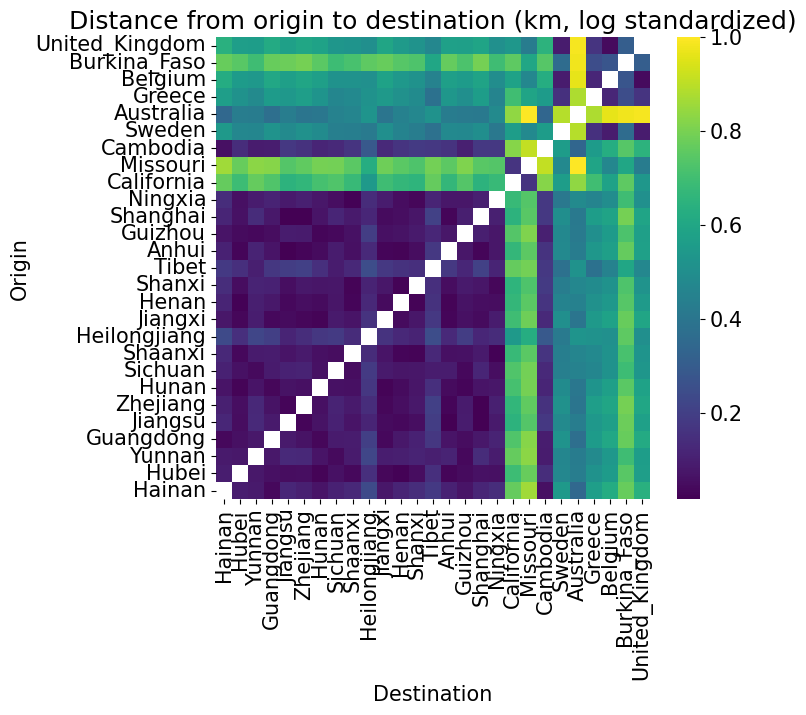

In [39]:
## Get centroid coordinates for the regions from geojson files
import os
path = '/mnt/c/Files/wumv6_phylogeo/regions_geojson'
for file in os.listdir(path):
    if file.endswith(".geojson"):
        filepath = os.path.join(path, file)
        gdf = gpd.read_file(filepath)
        gdf = gdf.to_crs(epsg=4326)
        gdf['centroid'] = gdf.geometry.centroid
    
        ## Extract longitude and latitude
        gdf['centroid_lon'] = gdf['centroid'].x
        gdf['centroid_lat'] = gdf['centroid'].y
        
        print(gdf[['name', 'centroid_lat', 'centroid_lon']])

# geojson file source for regions: https://www.osmtoday.com/


centroid_coords = {key: value for key, value in centroid_coords.items()}
## get the list of regions and region combinations
regions = NP_region_list
region_combinations = combinations(regions, 2)
distance_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)

## calculate distances and make the matrix:
for c1, c2 in region_combinations:
    coord1 = centroid_coords[c1]
    coord2 = centroid_coords[c2]
    # print(coord1, coord2)
    distance_km = geodesic(coord1, coord2).km
    distance_matrix.loc[c1, c2] = distance_km
    distance_matrix.loc[c2, c1] = distance_km

# print(distance_matrix)
np.fill_diagonal(distance_matrix.values, 0.0)

values = distance_matrix.values.flatten()
max_val = np.nanmax(values)
min_val = np.nanmin(values)

## normalize between 0 and 1
norm_matrix = (distance_matrix - min_val) / (max_val - min_val)

## convert back to DataFrame
df_std_distance = pd.DataFrame(norm_matrix, index=regions, columns=regions)
# print(df_std_distance)

df_std_distance.to_csv(
    "/mnt/c/Files/wumv6_phylogeo/predictors/wmv6_NP_distance_predictor_matrix.txt",
    sep="\t",
    float_format="%.8f"
)

plt.figure(figsize=(7, 6))
mask = np.zeros_like(df_std_distance, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(df_std_distance, cmap="viridis", mask=mask, xticklabels=True, yticklabels=True)
plt.title("Distance from origin to destination (km, log standardized)")
plt.xlabel("Destination")
plt.ylabel("Origin")
plt.gca().invert_yaxis()
plt.show()

## For number of sequences per region predictor

(array([[ 1.22605243,  1.22605243,  1.22605243,  1.22605243,  1.22605243,
          1.22605243,  1.22605243,  1.22605243,  1.22605243,  1.22605243,
          1.22605243,  1.22605243,  1.22605243,  1.22605243,  1.22605243,
          1.22605243,  1.22605243,  1.22605243,  1.22605243,  1.22605243,
          1.22605243,  1.22605243,  1.22605243,  1.22605243,  1.22605243,
          1.22605243,  1.22605243],
        [-0.56630361, -0.56630361, -0.56630361, -0.56630361, -0.56630361,
         -0.56630361, -0.56630361, -0.56630361, -0.56630361, -0.56630361,
         -0.56630361, -0.56630361, -0.56630361, -0.56630361, -0.56630361,
         -0.56630361, -0.56630361, -0.56630361, -0.56630361, -0.56630361,
         -0.56630361, -0.56630361, -0.56630361, -0.56630361, -0.56630361,
         -0.56630361, -0.56630361],
        [ 1.75256896,  1.75256896,  1.75256896,  1.75256896,  1.75256896,
          1.75256896,  1.75256896,  1.75256896,  1.75256896,  1.75256896,
          1.75256896,  1.75256896,  1.75

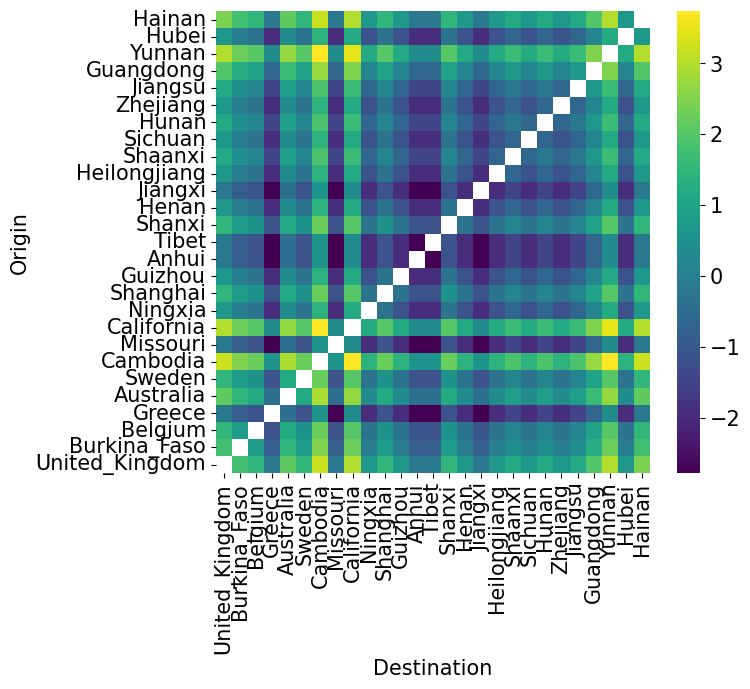

In [44]:
country_counts = {}
region_counts = {}

sequences = '/mnt/c/Files/wumv6_phylogeo/NP_wmv6_aln_cds.fasta'

with open(sequences, 'r') as seq:
    for record in SeqIO.parse(seq, "fasta"):
        parts = record.id.split('|')
        # print(record.id)
        country = parts[2]
        # region = parts[3]

        # Count countries
        if country not in country_counts:
            country_counts[country] = 0
        country_counts[country] += 1

# print(country_counts, region_counts)
seq_counts = {'Australia': 7, 'Sweden': 4, 'United_Kingdom': 9, 'California': 14, 'Missouri': 1, 'Greece': 1, 'Belgium': 4, 'Tibet': 1, 'Cambodia': 17, 'Burkina_Faso': 5, 'Hubei': 2, 'Jiangsu': 3, 'Hainan': 9, 'Yunnan': 14, 'Guangdong': 6, 'Henan': 2, 'Hunan': 3, 'Ningxia': 2, 'Shaanxi': 3, 'Shanxi': 4, 'Anhui': 1, 'Guizhou': 2, 'Heilongjiang': 2, 'Jiangxi': 1, 'Zhejiang': 2, 'Sichuan': 2, 'Shanghai': 4}

predictorMatrixPlot(seq_counts, NP_region_list, "seq_counts_per_region")

## For bird migration flyway predictors

In [47]:
path = '/mnt/c/Files/wumv6_phylogeo/regions_geojson'

region_list = []
for file in os.listdir(path):
    if file.endswith(".geojson"):
        filepath = os.path.join(path, file)
        gdf = gpd.read_file(filepath)   ## get geo data from file and save as GeoDataFrame (like DataFrame but has columns for geo data)
        region_list.append(gdf)
countries_gdf = gpd.GeoDataFrame(pd.concat(region_list)) 

## Create normalized lookup (lowercase + replace dash/space with underscore)
region_lookup = {
    r.lower().replace("-", "_").replace(" ", "_"): r
    for r in NP_region_list
}

## Normalize GeoJSON names
countries_gdf["name_clean"] = (
    countries_gdf["name"]
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

## Map to official names
countries_gdf["name"] = countries_gdf["name_clean"].map(region_lookup)

## Check for unmatched names
missing = countries_gdf[countries_gdf["name"].isna()]["name_clean"].unique()
print("Still unmatched:", missing)

## Keep only matched regions
countries_gdf = countries_gdf[countries_gdf["name"].notna()]

flyway_file = '/mnt/c/Files/wumv6_phylogeo/flyways/major_flyways.kml'
gdf_list = []
for layer in fiona.listlayers(flyway_file): 
    gdf = gpd.read_file(flyway_file, driver="KML", layer=layer) ## get geo data from kml file
    gdf["flyway"] = layer   ## add the layer name (which flwyay)
    gdf_list.append(gdf)
flyways_gdf = gpd.GeoDataFrame(pd.concat(gdf_list))
# print(flyways_gdf.head())

equal_area_crs = "EPSG:6933"
countries_proj = countries_gdf.to_crs(equal_area_crs) ## convert to World Cylindrical Equal Area projection (to calculate accurate areas)
flyways_proj   = flyways_gdf.to_crs(equal_area_crs)

overlaps = gpd.overlay(countries_proj, flyways_proj, how="intersection") ## overlap all gdf values at the same time and get intersecting points
overlaps["overlap_area"] = overlaps.area ## calculate area of the overlaps

country_areas = countries_proj.set_index("name").geometry.area ## build a Series mapping the country name → area
overlaps["country_area"] = overlaps["name"].map(country_areas) ## get the area and calculate overlap percentage (country/flyway)
overlaps["overlap_percent"] = overlaps["overlap_area"] / overlaps["country_area"] * 100

print(overlaps[["name", "flyway", "overlap_percent"]])

Still unmatched: ['chongqing' 'connecticut' 'tunisia' 'wyoming' 'yemen']
              name                   flyway  overlap_percent
0            Anhui          central_pacific        64.097603
1            Anhui  east_asian_australasian       100.000000
2        Australia          central_pacific        36.370629
3        Australia  east_asian_australasian        99.998451
4          Belgium            east_atlantic        99.998856
5     Burkina_Faso   blacksea_mediterranean       100.000000
6     Burkina_Faso            east_atlantic         7.207399
7       California     mississippi_americas         3.495440
8       California         pacific_americas        93.442485
9         Cambodia  east_asian_australasian       100.000000
10          Greece   blacksea_mediterranean       100.000000
11       Guangdong          central_pacific        21.431167
12       Guangdong  east_asian_australasian       100.000000
13         Guizhou  east_asian_australasian        99.996228
14          

In [48]:
flyway_country_overlap_dict = {}
for _, row in overlaps.iterrows():
    flyway = row["flyway"]
    country = row["name"]
    overlap_percent = row["overlap_percent"]

    flyway_dict = {region: 0 for region in NP_region_list}
    
    if flyway not in flyway_country_overlap_dict:
        flyway_country_overlap_dict[flyway] = {}
    if overlap_percent > 50: ## using those flyway/region overlaps that are larger than 50 %, save as 1
        flyway_country_overlap_dict[flyway][country] = 1
# print(flyway_country_overlap_dict)

regions = NP_region_list
flyway_matrices = {}

for flyway, country_dict in flyway_country_overlap_dict.items():
    for region in regions:
        if region not in country_dict:
            country_dict[region] = 0
    # print(flyway, country_dict)
    # print(flyway_country_overlap_dict)
    matrix = pd.DataFrame(0, index=regions, columns=regions)

    for r1 in regions:
        for r2 in regions:
            if country_dict[r1] == 1 and country_dict[r2] == 1:
                matrix.loc[r1, r2] = 1

    flyway_matrices[flyway] = matrix
    # print(flyway_matrices)

## save files
outdir = "/mnt/c/Files/wumv6_phylogeo/predictors/"

for flyway, matrix in flyway_matrices.items():
    filename = f"wmv6_NP_flyway_{flyway}_predictor_matrix.txt"
    filepath = os.path.join(outdir, filename)
    matrix.to_csv(filepath, sep="\t", float_format="%.8f")

## Example datasets:

In [29]:
NP_region_list = ["Hainan",
    "Hubei",
    "Yunnan",
    "Guangdong",
    "Jiangsu",
    "Zhejiang",
    "Hunan",
    "Sichuan",
    "Shaanxi",
    "Heilongjiang",
    "Jiangxi",
    "Henan",
    "Shanxi",
    "Tibet",
    "Anhui",
    "Guizhou",
    "Shanghai",
    "Ningxia",
    "California",
    "Missouri",
    "Cambodia",
    "Sweden",
    "Australia",
    "Greece",
    "Belgium",
    "Burkina_Faso",
    "United_Kingdom"]

annual_precipitation = { 
    "Hainan": 76.12,
    "Hubei": 42.92, 
    "Yunnan": 60.49, 
    "Guangdong": 104.36,
    "Jiangsu": 57.13,
    "Zhejiang": 76.86,
    "Hunan": 65.69, 
    "Sichuan": 65.43,
    "Shaanxi": 25.25,
    "Heilongjiang": 40.4,
    "Jiangxi": 81.62,
    "Henan": 27.66,
    "Shanxi": 23.45,
    "Tibet": 18.77,
    "Anhui": 74.53,
    "Guizhou": 97.82,
    "Shanghai": 67.1,
    'Ningxia': 19.93,
    "California": 30.48,
    "Missouri": 68.68,
    "Cambodia": 101.88,
    "Sweden": 70.62,
    "Australia": 27.19,
    "Greece": 41.64,
    "Belgium": 37.4,
    "Burkina_Faso": 33.57,
    "United_Kingdom": 61.25
}

precipitation_min_max_avg = {
    "Hainan": [14.32, 155.67],
    "Hubei": [6.82, 101.81],
    "Yunnan": [5.56, 165.62],
    "Guangdong": [19.55, 233.62],
    "Jiangsu": [21.61, 145.64],
    "Zhejiang": [24.64, 173.26],
    "Hunan": [23.35, 183.05],
    "Sichuan": [21.94, 175.2],
    "Shaanxi": [1.16, 66.3],
    "Heilongjiang": [3.37, 106.85],
    "Jiangxi": [21.86, 182.89],
    "Henan": [3.04, 80.14],
    "Shanxi": [1.61, 68.15],
    "Tibet": [0.85, 74.32],
    "Anhui": [27.63, 176.46],
    "Guizhou": [35.45, 228.74],
    "Shanghai": [31.97, 143.96],
    "Ningxia": [1.98, 143.96],
    "California": [1.35, 73.65],
    "Missouri": [41.38, 109.69],
    "Cambodia": [10.63, 213.06],
    "Sweden": [45.16, 94.04],
    "Australia": [18.28, 43.16],
    "Greece": [16.31, 65.16],
    "Belgium": [23.29, 53.2],
    "Burkina_Faso": [0.11, 134.17],
    "United_Kingdom": [42.1, 75.63]
}

neighboring_countries = {
    ##### countries divided to regions:
    "Hubei": ["Anhui", "Chongquing", "Henan", "Hunan", "Jiangxi", "Shaanxi"],
    "Yunnan": ["Tibet", "Sichuan", "Guizhou", "Guangxi"], 
    "Guangdong": ["Hainan", "Guangxi", "Hunan", "Jiangxi", "Fujian"],
    "Jiangsu": ["Anhui", "Shandong", "Shanghai", "Zhejiang"],    
    "Hainan": ["Guangdong"],
    "Zhejiang": ["Jiangsu", "Shanghai", "Anhui", "Jiangxi", "Fujian"], 
    "Hunan": ["Hubei", "Jiangxi", "Guangdong", "Guangxi", "Guizhou", "Chongquing"],
    "Sichuan": ["Qinghai", "Gansu", "Shaanxi", "Chongquing", "Guizhou", "Yunnan", "Tibet"],
    "Shaanxi": ["Ningxia", "Inner Mongolia", "Shanxi", "Henan", "Hubei", "Chongquing", "Sichuan", "Gansu"],
    "Heilongjiang": ["Inner Mongolia", "Jilin"],
    "Jiangxi": ["Hubei", "Anhui", "Zhejiang", "Fujian", "Guangdong", "Hunan"],
    "Henan": ["Shanxi", "Hebei", "Shandong", "Anhui", "Hubei", "Shaanxi"],
    "Shanxi": ["Shaanxi", "Inner Mongolia", "Hebei", "Henan"],
    "Tibet": ["Xinjiang", "Quinghai", "Sichuan", "Yunnan"],
    "Anhui": ["Shandong", "Jiangsu", "Zhejiang", "Jiangxi", "Hubei", "Henan"],
    "Guizhou": ["Sichuan", "Chongquing", "Hunan", "Guangxi", "Yunnan"],
    "Shanghai": ["Jiangsu", "Zhejiang"],
    'Ningxia': ['Inner Mongolia', 'Gansu', 'Shaanxi'],
    "California": ["Oregon", "Nevada", "Arizona"],
    "Missouri": ["Iowa", "Kansas", "Oklahoma", "Arkansas", "Tennessee", "Kentucky", "Nebraska", "Illinois"],
    ##### countries not divided to regions:
    "Cambodia": ["Laos", "Thailand", "Vietnam"],
    "Sweden": ["Finland", "Norway"],
    "Australia": [],
    "Greece": ["Albania", "Bulgaria", "Turkey", "North Macedonia"], 
    "Belgium": ["France", "Germany", "Netherlands", "Luxembourg"],
    "Burkina_Faso": ["Mali", "Benin", "Ghana", "Niger", "Togo", "Ivory_Coast"],
    "United_Kingdom": ["Ireland"]
}

centroid_coords = { #lat, lon
    "Hainan": [17.883595, 111.241771], 
    "Hubei": [30.972024, 112.257427],
    "Yunnan": [24.990533, 101.493693],
    "Guangdong": [22.912986, 113.341439],
    "Jiangsu": [33.067097, 119.7861],
    "Zhejiang": [29.192334, 120.607438],
    "Hunan": [27.600015, 111.706841],
    "Sichuan": [30.62974, 102.703169],
    "Shaanxi": [35.198317, 108.863901],
    "Heilongjiang": [47.885373, 127.739911],
    "Jiangxi": [27.608893, 115.720748],
    "Henan": [33.887657, 113.631526],
    "Shanxi": [37.576541, 112.295133],
    "Tibet": [31.68782, 88.13869],
    "Anhui": [31.832276, 117.228039],
    "Guizhou": [26.819968, 106.875671],
    "Shanghai": [31.19908, 121.904123],
    'Ningxia': [37.264947, 106.163951],
    "California": [36.551343, -121.320102],
    "Missouri": [38.365445, -92.470336],
    "Cambodia": [12.565679, 104.990963],
    "Sweden": [60.128161, 18.643501],
    "Australia": [-25.274398, 133.775136],
    "Greece": [39.074208, 21.824312],
    "Belgium": [50.503887, 4.469936],
    "Burkina_Faso": [12.238333, -1.561593],
    "United_Kingdom": [54.759108, -3.388315]
}

seq_counts = {
    'Australia': 7, 
    'Sweden': 4, 
    'California': 14, 
    'Missouri': 1, 
    'Greece': 1, 
    'Belgium': 4, 
    'Tibet': 1, 
    'Cambodia': 17, 
    'Burkina_Faso': 5, 
    'Hubei': 2, 
    'Jiangsu': 3, 
    'Hainan': 9, 
    'Yunnan': 14, 
    'Guangdong': 6, 
    'Henan': 2, 
    'Hunan': 3, 
    'Ningxia': 2, 
    'Shaanxi': 3, 
    'Shanxi': 4, 
    'Anhui': 1, 
    'Guizhou': 2, 
    'Heilongjiang': 2, 
    'Jiangxi': 1, 
    'Zhejiang': 2, 
    'Sichuan': 2, 
    'Shanghai': 4
}

